# Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif

# Descripcion del Dataset y fuente

**Fuente**: https://www.kaggle.com/datasets/mahmoudelhemaly/students-grading-dataset?select=Students+Performance+Dataset.csv

**Descripción de la muestra**: 5.000 observaciones de estudiantes y 23 variables que combinan métricas académicas (calificaciones parciales, tareas, proyectos), conductuales (asistencia, horas de estudio, sueño, estrés), sociodemográficas (edad, género, nivel educativo de los padres, ingresos familiares) y datos de identificación (Student_ID, First_Name, Last_Name, Email).

# Carga de datos

In [2]:
df = pd.read_csv('datos/estudiantes.csv')
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado: 5000 filas, 23 columnas


# Problema a resolver

Identificar de manera anticipada el nivel de rendimiento académico final de los estudiantes categorizado en su calificación (A, B, C, D o F) a partir de sus hábitos de estudio, asistencia y factores contextuales.

**Variable objetivo: "Calificacion".**

# Exploracion

In [3]:
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [4]:
mapeo_columnas = {
    "Student_ID": "ID_Estudiante",
    "First_Name": "Nombre",
    "Last_Name": "Apellido",
    "Email": "Correo_Electronico",
    "Gender": "Genero",
    "Age": "Edad",
    "Department": "Departamento",
    "Attendance (%)": "Asistencia (%)",
    "Midterm_Score": "Nota_Parcial",
    "Final_Score": "Nota_Final",
    "Assignments_Avg": "Promedio_Tareas",
    "Quizzes_Avg": "Promedio_Quices",
    "Participation_Score": "Puntaje_Participacion",
    "Projects_Score": "Puntaje_Proyectos",
    "Total_Score": "Puntaje_Total",
    "Grade": "Calificacion",
    "Study_Hours_per_Week": "Horas_Estudio_por_Semana",
    "Extracurricular_Activities": "Actividades_Extracurriculares",
    "Internet_Access_at_Home": "Acceso_Internet_en_Hogar",
    "Parent_Education_Level": "Nivel_Educativo_Padres",
    "Family_Income_Level": "Nivel_Ingreso_Familiar",
    "Stress_Level (1-10)": "Nivel_Estres_(1-10)",
    "Sleep_Hours_per_Night": "Horas_Sueno_por_Noche"
}

df = df.rename(columns=mapeo_columnas)
df.columns.tolist()

['ID_Estudiante',
 'Nombre',
 'Apellido',
 'Correo_Electronico',
 'Genero',
 'Edad',
 'Departamento',
 'Asistencia (%)',
 'Nota_Parcial',
 'Nota_Final',
 'Promedio_Tareas',
 'Promedio_Quices',
 'Puntaje_Participacion',
 'Puntaje_Proyectos',
 'Puntaje_Total',
 'Calificacion',
 'Horas_Estudio_por_Semana',
 'Actividades_Extracurriculares',
 'Acceso_Internet_en_Hogar',
 'Nivel_Educativo_Padres',
 'Nivel_Ingreso_Familiar',
 'Nivel_Estres_(1-10)',
 'Horas_Sueno_por_Noche']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID_Estudiante                  5000 non-null   str    
 1   Nombre                         5000 non-null   str    
 2   Apellido                       5000 non-null   str    
 3   Correo_Electronico             5000 non-null   str    
 4   Genero                         5000 non-null   str    
 5   Edad                           5000 non-null   int64  
 6   Departamento                   5000 non-null   str    
 7   Asistencia (%)                 4484 non-null   float64
 8   Nota_Parcial                   5000 non-null   float64
 9   Nota_Final                     5000 non-null   float64
 10  Promedio_Tareas                4483 non-null   float64
 11  Promedio_Quices                5000 non-null   float64
 12  Puntaje_Participacion          5000 non-null   float64
 13 

In [6]:
df.describe()

,Edad,Asistencia (%),Nota_Parcial,Nota_Final,Promedio_Tareas,Promedio_Quices,Puntaje_Participacion,Puntaje_Proyectos,Puntaje_Total,Horas_Estudio_por_Semana,Nivel_Estres_(1-10),Horas_Sueno_por_Noche
count,5000.000000,4484.000000,5000.000000,5000.000000,4483.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,21.048400,75.431409,70.326844,69.640788,74.798673,74.910728,4.980024,74.924860,75.121804,17.658860,5.48080,6.488140
std,1.989786,14.372446,17.213209,17.238744,14.411799,14.504281,2.890136,14.423415,14.399941,7.275864,2.86155,1.452283
min,18.000000,50.010000,40.000000,40.000000,50.000000,50.030000,0.000000,50.010000,50.020000,5.000000,1.00000,4.000000
25%,19.000000,63.265000,55.457500,54.667500,62.090000,62.490000,2.440000,62.320000,62.835000,11.400000,3.00000,5.200000
50%,21.000000,75.725000,70.510000,69.735000,74.810000,74.695000,4.955000,74.980000,75.395000,17.500000,5.00000,6.500000
75%,23.000000,87.472500,84.970000,84.500000,86.970000,87.630000,7.500000,87.367500,87.652500,24.100000,8.00000,7.700000
max,24.000000,100.000000,99.980000,99.980000,99.980000,99.960000,10.000000,100.000000,99.990000,30.000000,10.00000,9.000000


In [7]:
total_nulos = df.isnull().sum().sum()
print(f"Cantidad total de valores nulos: {total_nulos}")

Cantidad total de valores nulos: 2827


In [8]:
cantidad_duplicados = df.duplicated().sum()
print(f"Cantidad de registros duplicados: {cantidad_duplicados}")

Cantidad de registros duplicados: 0


### Valores nulos

In [9]:
nulos_por_columna = df.isnull().sum()
nulos_por_columna = nulos_por_columna[nulos_por_columna > 0].sort_values(ascending=False)

resultado_nulos = pd.DataFrame({
    'Valores nulos': nulos_por_columna,
    'Porcentaje (%)': (nulos_por_columna / len(df) * 100).round(2)
})

resultado_nulos

,Valores nulos,Porcentaje (%)
Nivel_Educativo_Padres,1794,35.88
Promedio_Tareas,517,10.34
Asistencia (%),516,10.32


In [ ]:
# Crear banderas binarias de datos faltantes (1 = Nulo, 0 = Presente)
df['Nulo_Asistencia'] = df['Asistencia (%)'].isnull().astype(int)
df['Nulo_Tareas'] = df['Promedio_Tareas'].isnull().astype(int)
df['Nulo_Educacion_Padres'] = df['Nivel_Educativo_Padres'].isnull().astype(int)

# Diagnóstico MAR vs MCAR: Tasa de nulos según la Calificación
diagnostico_mcar_mar = pd.DataFrame({
    '% Nulos Asistencia': (df.groupby('Calificacion')['Nulo_Asistencia'].mean() * 100).round(2),
    '% Nulos Tareas': (df.groupby('Calificacion')['Nulo_Tareas'].mean() * 100).round(2),
    '% Nulos Nivel Padres': (df.groupby('Calificacion')['Nulo_Educacion_Padres'].mean() * 100).round(2)
})

print("Evaluación de mecanismos de ausencia según Calificación:")
diagnostico_mcar_mar

Evaluación de mecanismos de ausencia según Calificación:


,% Nulos Asistencia,% Nulos Tareas,% Nulos Nivel Padres
Calificacion,,,
A,7.02,10.03,36.66
B,10.43,10.63,35.07
C,11.21,10.20,35.52
D,10.57,10.35,33.75
F,14.93,10.66,38.03



| Variable con Nulos | % Faltante | Tipo | Justificación | Preparación |
| :--- | :---: | :---: | :--- | :--- |
| **`Promedio_Tareas`** | 10.34% | **MCAR** | La tasa de ausencia es similar en todas las categorías de rendimiento (`Grade` A: 10.0%, B: 10.6%, C: 10.2%, D: 10.3%, F: 10.7%). La omisión es independiente | Imputación por la mediana para no alterar la distribución original. |
| **`Asistencia (%)`** | 10.32% | **MAR** | La ausencia se correlaciona con el rendimiento final: los estudiantes con calificación `A` presentan un 7.02% de nulos, mientras que en la categoría `F` asciende al 14.93% (más del doble). | Imputar mediante técnica multivariada (KNN Imputer) o mediana condicionada por grupo post-partición. |
| **`Nivel_Educativo_Padres`** | 35.88% | **MCAR** | La tasa se reparte uniformemente (~36% en cada nivel de ingresos).| Por superar el 30% de vacíos, se descarta la eliminación de filas o la imputación numérica forzada. Se codifica explícitamente como una nueva categoría: `'Desconocido'` / `'No Informado'`. |

A considerar: distribuciones, variables a eliminar: ID, nombre, apellido, email.

# Graficos

### Variables mas relevantes

In [11]:
pass

### Outliers

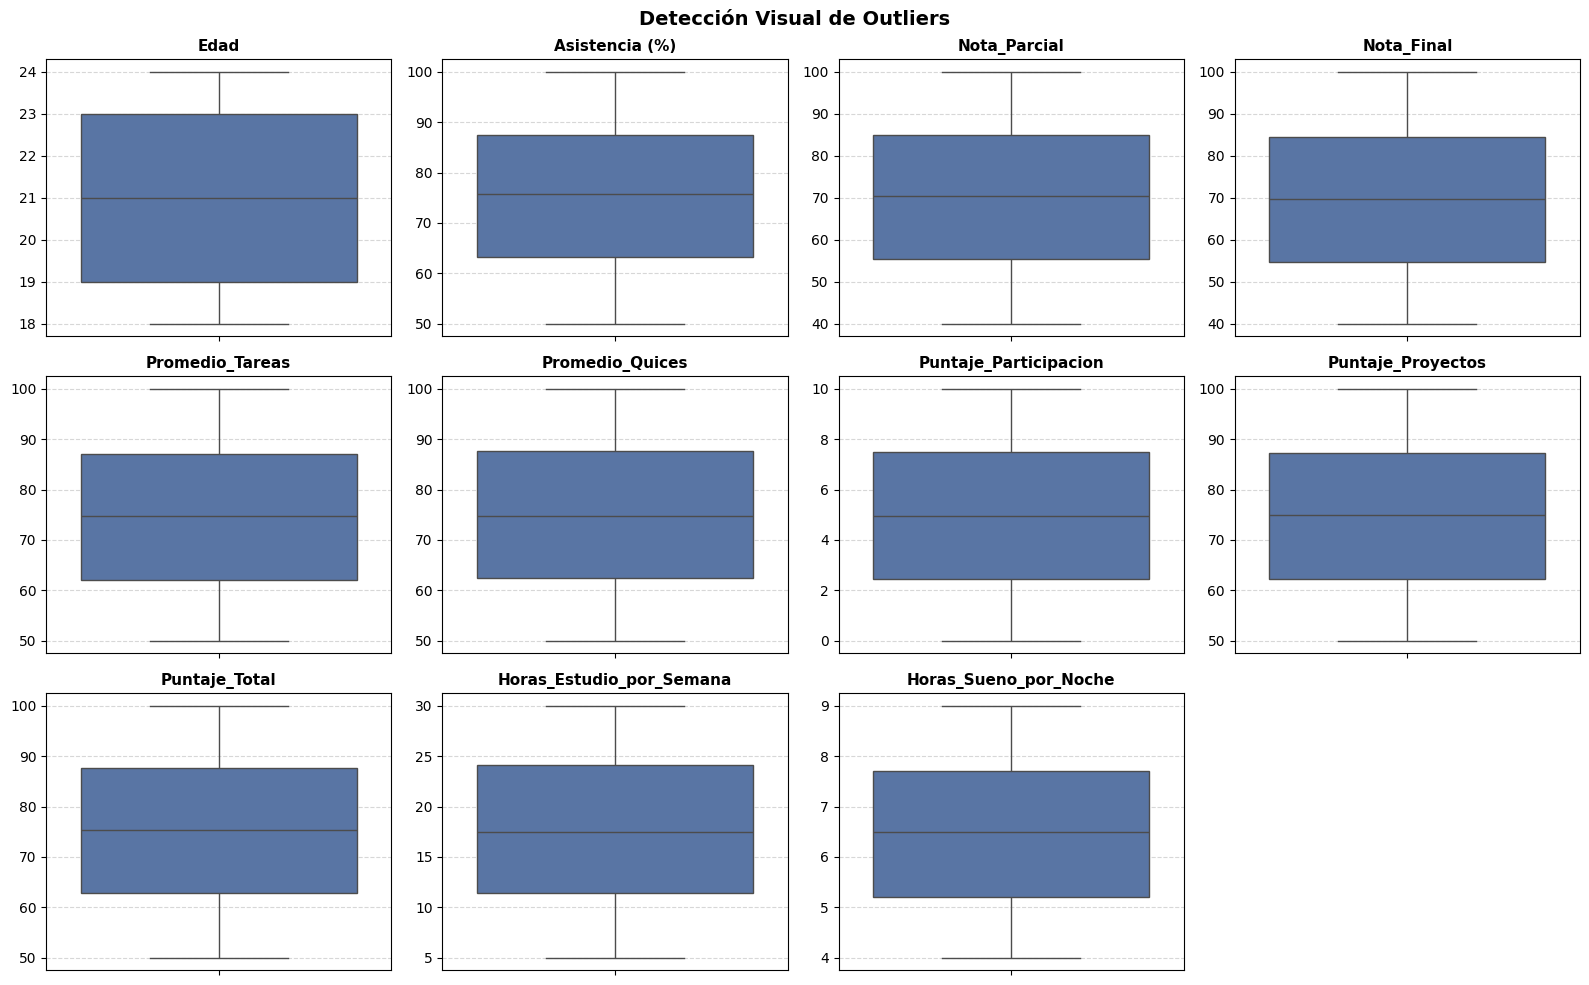

In [12]:
# Variables numéricas
columnas_boxplot = [
    'Edad', 'Asistencia (%)', 'Nota_Parcial', 'Nota_Final', 
    'Promedio_Tareas', 'Promedio_Quices', 'Puntaje_Participacion', 
    'Puntaje_Proyectos', 'Puntaje_Total', 'Horas_Estudio_por_Semana', 
    'Horas_Sueno_por_Noche'
]

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_boxplot):
    sns.boxplot(
        y=df[col], 
        ax=axes[i], 
        color='#4C72B0', 
        flierprops=dict(marker='o', markerfacecolor='crimson', markersize=4, alpha=0.7)
    )
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Ocultar el último cuadro vacío de la grilla 3x4
axes[-1].axis('off')

plt.suptitle('Detección Visual de Outliers', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Ninguna variable presenta puntos más allá de los bigotes

### Distribución de notas y asistencia

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14560\3272365944.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Calificacion', order=['A', 'B', 'C', 'D', 'F'], ax=axes[2], palette='viridis')


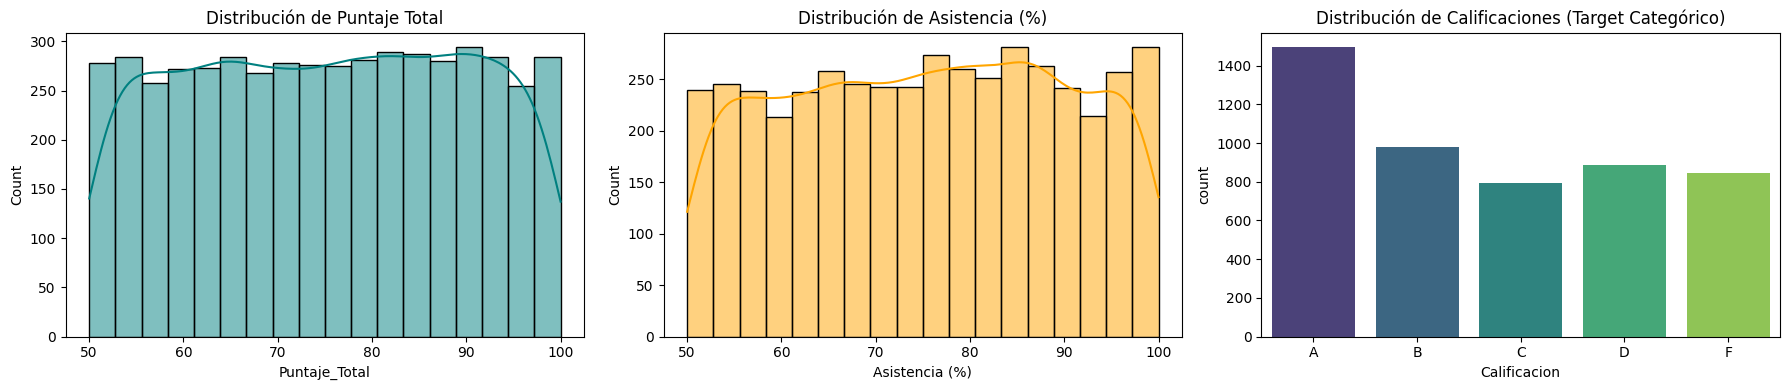

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df['Puntaje_Total'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribución de Puntaje Total')

sns.histplot(df['Asistencia (%)'].dropna(), kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribución de Asistencia (%)')

sns.countplot(data=df, x='Calificacion', order=['A', 'B', 'C', 'D', 'F'], ax=axes[2], palette='viridis')
axes[2].set_title('Distribución de Calificaciones (Target Categórico)')

plt.tight_layout()
plt.show()


- Puntaje_Total:
    - La distribución de la nota total parece estar centrada en un rango intermedio-alto, con una forma relativamente homogénea y sin fuertes asimetrías.
    - Esto sugiere que la mayoría de los estudiantes obtiene calificaciones moderadas a buenas, con pocos casos extremos bajos o altos.

- Asistencia (%):
    - La asistencia muestra una distribución bastante concentrada en valores altos.
    - Esto indica que la mayoría de los estudiantes asiste de forma regular.

- Calificacion:
    - La distribución por categorías (A, B, C, D, F) parece estar sesgada hacia las notas medias y altas, especialmente A/B/C.
    - Esto sugiere que la mayoría de los estudiantes no está reprobando y que el rendimiento académico general del dataset es bastante aceptable.

El conjunto tiene un rendimiento académico relativamente bueno, con asistencia generalmente alta y pocas calificaciones muy bajas.

### BoxPlot de Asistencia según Calificación

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14560\2573610494.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Calificacion', y='Asistencia (%)', order=['A', 'B', 'C', 'D', 'F'], palette='Set2')


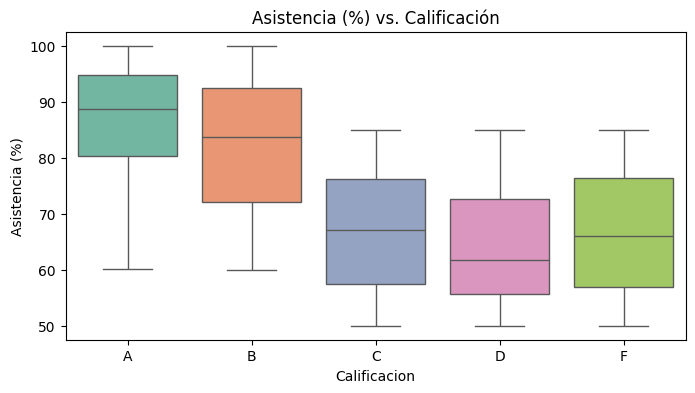

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Calificacion', y='Asistencia (%)', order=['A', 'B', 'C', 'D', 'F'], palette='Set2')
plt.title('Asistencia (%) vs. Calificación')
plt.show()

La asistencia tiende a ser más alta en los estudiantes con mejores calificaciones (A-B). Esto sugiere que la regularidad en la clase está fuertemente asociada con un mejor rendimiento académico.